In [174]:
import torch
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [40]:
import numpy as np
import torch
# 读取.npy文件
eta00 = np.load('data/1000_1s_data_eta00.npy')
eta00.shape

(1000, 720, 320)

In [185]:
import numpy as np
import torch
# 读取.npy文件
eta00 = np.load('data/1000_1s_data_eta00.npy')
eta = eta00[:-1,1,:]
tensor = torch.tensor(eta)
tensor_transposed = torch.transpose(tensor, 0, 1)

# 添加一个维度，变成形状为 (320, 32, 1) 的张量
tensor_reshaped = torch.unsqueeze(tensor_transposed, -1)

# 打印转换后张量的形状
print(tensor_reshaped.shape)
x = tensor_reshaped[:,:-1,:].float().to('cuda')
y = tensor_reshaped[:,1:,:].float().to('cuda')

torch.Size([320, 999, 1])


In [186]:
import torch.nn as nn
class Net(nn.Module):
    def __init__(self, ):
        super(Net, self).__init__() #调用了父类 nn.Module 的构造函数

        self.rnn = nn.GRU(
            input_size=1,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
        )
        for p in self.rnn.parameters():
            nn.init.normal_(p, mean=0.0, std=0.001)   # 对参数进行初值化

        self.linear = nn.Linear(256, 1)

    def forward(self, x, hidden_prev):
        out, hidden_prev = self.rnn(x, hidden_prev)  # [b, seq, h]
        out = self.linear(out)
        return out, hidden_prev

In [188]:

import torch.optim as optim

model = Net().to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), 0.001)

hidden_prev = torch.zeros(2, 320, 256).to('cuda')

for epoch in range(100):
    output, hidden_prev = model(x, hidden_prev)
    hidden_prev = hidden_prev.detach()
    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print("Iteration:{} loss {}".format(iter, loss.item()))

Iteration:<built-in function iter> loss 0.03020497038960457
Iteration:<built-in function iter> loss 0.02651211805641651
Iteration:<built-in function iter> loss 0.02471105195581913
Iteration:<built-in function iter> loss 0.013024410232901573
Iteration:<built-in function iter> loss 0.00471276743337512
Iteration:<built-in function iter> loss 0.004501571413129568
Iteration:<built-in function iter> loss 0.003162292530760169
Iteration:<built-in function iter> loss 0.0029747483786195517
Iteration:<built-in function iter> loss 0.0029016598127782345
Iteration:<built-in function iter> loss 0.0028174840845167637


In [189]:
tensor_expanded = torch.unsqueeze(y[:,997,:], dim=1)

In [190]:
(pred, hidden_prev) = model(tensor_expanded, hidden_prev)
pred.view(320)
a = pred.cpu().view(320).detach().numpy()

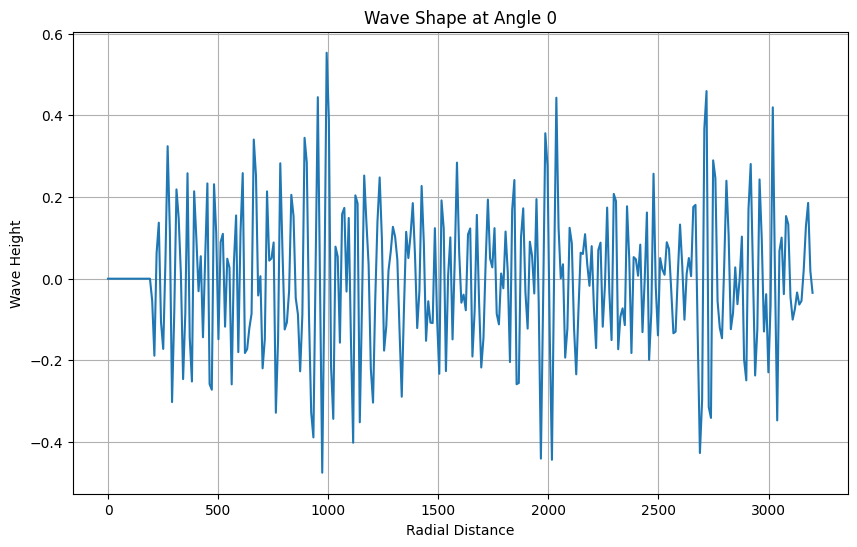

In [192]:
import matplotlib.pyplot as plt

# 选择第一帧数据和第一个角度
frame_index = 999
angle_index = 1
eta_frame = eta00[frame_index]
eta_angle = eta_frame[angle_index]

# 设置径向范围
r_values = np.linspace(0, 3200, 320)

# 可视化波浪形状
plt.figure(figsize=(10, 6))
plt.plot(r_values, eta_angle)
# plt.plot(r_values, a)
plt.title('Wave Shape at Angle 0')
plt.xlabel('Radial Distance')
plt.ylabel('Wave Height')
plt.grid(True)
plt.show()

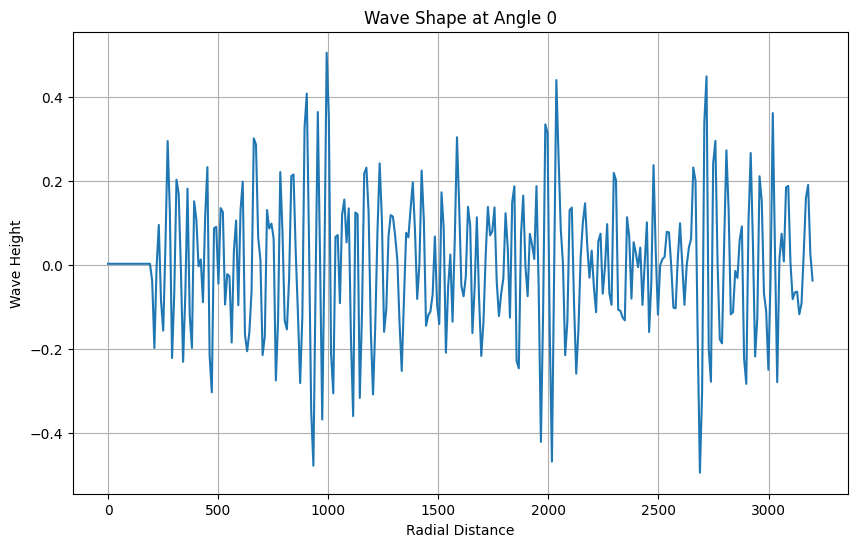

In [195]:
import matplotlib.pyplot as plt

# 选择第一帧数据和第一个角度
frame_index = 999
angle_index = 1
eta_frame = eta00[frame_index]
eta_angle = eta_frame[angle_index]

# 设置径向范围
r_values = np.linspace(0, 3200, 320)

# 可视化波浪形状
plt.figure(figsize=(10, 6))
# plt.plot(r_values, eta_angle)
plt.plot(r_values, a)
plt.title('Wave Shape at Angle 0')
plt.xlabel('Radial Distance')
plt.ylabel('Wave Height')
plt.grid(True)
plt.show()

In [19]:
import random
def seq_data_iter_random(corpus, batch_size, num_steps):  
    """使用随机抽样生成一个小批量子序列"""
    # 从随机偏移量开始对序列进行分区，随机范围包括num_steps-1
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 减去1，是因为我们需要考虑标签
    num_subseqs = (len(corpus) - 30) // num_steps
    # 长度为num_steps的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 在随机抽样的迭代过程中，
    # 来自两个相邻的、随机的、小批量中的子序列不一定在原始序列上相邻
    random.shuffle(initial_indices)

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos: pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

In [21]:
my_seq = list(range(35))
for X, Y in seq_data_iter_random(my_seq, batch_size=2, num_steps=80):
    print('X: ', X, '\nY:', Y)

ValueError: only one element tensors can be converted to Python scalars

In [22]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):  #@save
    """使用顺序分区生成一个小批量子序列"""
    # 从随机偏移量开始划分序列
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

In [149]:
corpus = torch.randn(1000,720,320)
batch_size = 4
num_steps = 100

In [140]:
# Example usage:
# Define model parameters
cnn_channels = 64
rnn_hidden_size = 128
rnn_layers = 2
num_classes = 10

# Create model instance
model = WaveNet(64, 128, 2, 10)

# Example input
batch_size = 32
sequence_length = 100
input_channels = 1
input_data = torch.randn(batch_size, input_channels, sequence_length)

# Forward pass
output = model(input_data)
print("Output shape:", output.shape)

        self.fc = nn.Linear(in_features=cnn_channels, out_features=num_classes)

IndentationError: unexpected indent (436908620.py, line 21)

In [ ]:
output.size()

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size1, kernel_size2, stride1, stride2):
        super(SimpleCNN, self).__init__()
        
        # 第一个卷积层
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=output_channels, kernel_size=kernel_size1, stride=stride1)
        self.relu1 = nn.ReLU()
        
        # 第二个卷积层
        self.conv2 = nn.Conv1d(in_channels=output_channels, out_channels=output_channels, kernel_size=kernel_size2, stride=stride2)
        self.relu2 = nn.ReLU()
        
        # 池化层
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # 全连接层
        self.fc = nn.Linear(output_channels, 10)  # 假设输出维度为10

    def forward(self, x):
        # 第一层卷积 + ReLU
        x = self.relu1(self.conv1(x))
        
        # 池化
        x = self.pool(x)
        
        # 第二层卷积 + ReLU
        x = self.relu2(self.conv2(x))
        
        # 池化
        x = self.pool(x)
        
        # 将特征拉平
        x = x.view(x.size(0), -1)
        
        # 全连接层
        x = self.fc(x)
        return x

# 实例化模型
input_channels = 3  # 输入通道数
output_channels = 16  # 输出通道数
kernel_size1 = 3  # 第一个卷积核大小
kernel_size2 = 3  # 第二个卷积核大小
stride1 = 1  # 第一个卷积步长
stride2 = 1  # 第二个卷积步长
model = SimpleCNN(input_channels, output_channels, kernel_size1, kernel_size2, stride1, stride2)

# 打印模型结构
print(model)


In [1]:
import torch

# 创建一个大小为 (20, 10) 的张量
tensor = torch.randn(20, 10)

# 在第一个维度上增加一个维度
reshaped_tensor = tensor.unsqueeze(0)

# 输出增加维度后的张量形状
print(reshaped_tensor.size())

torch.Size([1, 20, 10])


In [13]:
import torch.nn as nn
a = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=3, padding=1)
b = nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, padding=1)
c = nn.Conv2d(in_channels=10, out_channels=1, kernel_size=3, padding=1)
d = nn.MaxPool2d(kernel_size=2, stride=2)
e = nn.Flatten()
input1 = torch.rand(20,1,720,320)
out1 = a(input1)
out2 = b(out1)
out3 = c(out2)
out4 = d(out3)
out5 = e(out4)
out5.size()

torch.Size([20, 57600])

torch.Size([20, 10, 720, 320])

In [34]:
import torch
import random
def seq_data_iter_random(corpus, batch_size, num_steps):
    """使用随机抽样生成一个小批量子序列

    Defined in :numref:`sec_language_model`"""
    # 从随机偏移量开始对序列进行分区，随机范围包括num_steps-1
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 减去1，是因为我们需要考虑标签
    num_subseqs = (len(corpus) - 30) // num_steps
    # 长度为num_steps的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 在随机抽样的迭代过程中，
    # 来自两个相邻的、随机的、小批量中的子序列不一定在原始序列上相邻
    random.shuffle(initial_indices)

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos: pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 30) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)


In [35]:
# input_data = torch.rand(1000,720,320)
import numpy as np

# 生成随机数组，大小为 (1000, 720, 320)
array = np.random.randn(1000,720,320)

for X, Y in seq_data_iter_random(array, batch_size=1, num_steps=80):
    output, hidden_prev = model(x, hidden_prev)
    hidden_prev = hidden_prev.detach()

    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()

    optimizer.step()

    if iter % 100 == 0:
        print("Iteration:{} loss {}".format(iter, loss.item()))
    print('X: ', X, '\nY:', Y)

X:  tensor([[[[ 0.2752, -2.8990, -0.2374,  ..., -1.8921,  1.3651,  1.3545],
          [-1.3144,  0.6454, -0.9524,  ..., -0.9108, -1.4161, -0.1433],
          [ 0.9069,  0.3211, -0.7267,  ..., -1.2762, -0.4565,  1.1989],
          ...,
          [ 0.9811,  0.0190, -0.3669,  ...,  0.4258, -2.9097,  1.8591],
          [-2.4497,  0.2877, -0.6973,  ..., -0.2971, -1.1773, -1.3137],
          [ 0.8001, -0.0681, -0.8835,  ..., -1.0456, -1.2384,  0.0579]],

         [[-0.0541,  0.7092,  0.1590,  ...,  1.0959,  0.4263, -0.4120],
          [ 0.0936,  0.0349, -1.5714,  ..., -1.6352,  0.1916, -1.0752],
          [-0.1206, -0.3482,  0.3805,  ...,  1.0450, -1.9316,  0.8333],
          ...,
          [ 1.0392,  1.8657,  1.8006,  ...,  0.0480, -0.0816, -0.1025],
          [-0.8080,  0.3157, -0.5170,  ...,  0.7405,  0.5316, -1.3100],
          [-1.6255, -1.1331, -1.0061,  ...,  0.5609,  2.0865, -1.0700]],

         [[ 0.3203, -0.1204, -1.4983,  ...,  0.9292,  0.7567,  0.9745],
          [-0.6558, -0.645

In [37]:
X.size()
X = X.permute(1, 0, 2, 3)
X.size()

torch.Size([80, 1, 720, 320])

In [21]:
Y.size()

torch.Size([2, 80, 720, 320])

In [41]:
for iter in range(6000):
    start = np.random.randint(3, size=1)[0]
    time_steps = np.linspace(start, start + 10, num_time_steps)
    data = np.sin(time_steps)
    x = torch.tensor(data[:-1]).float().view(1, num_time_steps - 1, 1)
    y = torch.tensor(data[1:]).float().view(1, num_time_steps - 1, 1)

    output, hidden_prev = model(x, hidden_prev)
    hidden_prev = hidden_prev.detach()

    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()

    optimizer.step()

    if iter % 100 == 0:
        print("Iteration:{} loss {}".format(iter, loss.item()))

NameError: name 'num_time_steps' is not defined

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
import torch
import torch.optim as optim


class WaveNet(nn.Module):
    def __init__(self, cnn_channels, rnn_hidden_size, rnn_layers):
        super(WaveNet, self).__init__()
        self.cnn_channels = cnn_channels
        self.rnn_hidden_size = rnn_hidden_size # 252
        self.rnn_layers = rnn_layers

        # CNN layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=cnn_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=cnn_channels, out_channels=cnn_channels, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=cnn_channels, out_channels=1, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()

        # RNN layers
        self.rnn = nn.GRU(input_size=57600, hidden_size=rnn_hidden_size, num_layers=rnn_layers, batch_first=True)

        # # CNN layers after RNN
        # self.conv3 = nn.Conv1d(in_channels=rnn_hidden_size, out_channels=cnn_channels, kernel_size=3, padding=1)
        # self.conv4 = nn.Conv1d(in_channels=cnn_channels, out_channels=cnn_channels, kernel_size=3, padding=1)

        # Output layer
        self.fc = nn.Linear(in_features=rnn_hidden_size, out_features=230400)

    def forward(self, x):
        # CNN layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.flatten(x)
        print(x.size())

        # Reshape for RNN
        x = x.unsqueeze(0) # Change shape from [batch_size, channels, sequence_length] to [batch_size, sequence_length, channels]

        # RNN layers
        x, _ = self.rnn(x)


        # Output layer
        x = self.fc(x)

        x = x.view(80,720,320)
        return x
def seq_data_iter_random(corpus, batch_size, num_steps):
    """使用随机抽样生成一个小批量子序列

    Defined in :numref:`sec_language_model`"""
    # 从随机偏移量开始对序列进行分区，随机范围包括num_steps-1
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 减去1，是因为我们需要考虑标签
    num_subseqs = (len(corpus) - 30) // num_steps
    # 长度为num_steps的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 在随机抽样的迭代过程中，
    # 来自两个相邻的、随机的、小批量中的子序列不一定在原始序列上相邻
    random.shuffle(initial_indices)
    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos: pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 30) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

# 读取.npy文件
eta00 = np.load('data/1000_1s_data_eta00.npy')
model = WaveNet(64, 256, 1).to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), 0.01)


for X, Y in seq_data_iter_random(eta00, batch_size=1, num_steps=80):
    X = X.permute(1, 0, 2, 3).float().to('cuda')
    output = model(X)
    # output, hidden_prev = model(X, hidden_prev)
    # hidden_prev = hidden_prev.detach()
    Y = Y.squeeze().float().to('cuda')
    loss = criterion(output, Y)
    model.zero_grad()
    loss.backward()

    optimizer.step()


    print("Iteration:{} loss {}".format(iter, loss.item()))

torch.Size([80, 57600])
Iteration:0 loss 0.0311567522585392
torch.Size([80, 57600])
Iteration:0 loss 0.02887900546193123
torch.Size([80, 57600])
Iteration:0 loss 0.028274308890104294
torch.Size([80, 57600])
Iteration:0 loss 0.028102807700634003
torch.Size([80, 57600])
Iteration:0 loss 0.028021585196256638
torch.Size([80, 57600])
Iteration:0 loss 0.027938464656472206
torch.Size([80, 57600])
Iteration:0 loss 0.02803068421781063
torch.Size([80, 57600])
Iteration:0 loss 0.028963102027773857
torch.Size([80, 57600])
Iteration:0 loss 0.02801094390451908
torch.Size([80, 57600])
Iteration:0 loss 0.02819857746362686
torch.Size([80, 57600])
Iteration:0 loss 0.02817615307867527


In [56]:
eta00 = np.load('data/1000_1s_data_eta00.npy')
eat00_1_input = eta00[:80]
tensor = torch.tensor(eat00_1_input).unsqueeze(1).float().to('cuda')
tensor.size()

torch.Size([80, 1, 720, 320])

In [57]:
pred = model(tensor)

torch.Size([80, 57600])


In [58]:
pred.size()

torch.Size([80, 720, 320])

In [63]:
a = pred.cpu().detach().numpy()

In [64]:
a.shape

(80, 720, 320)

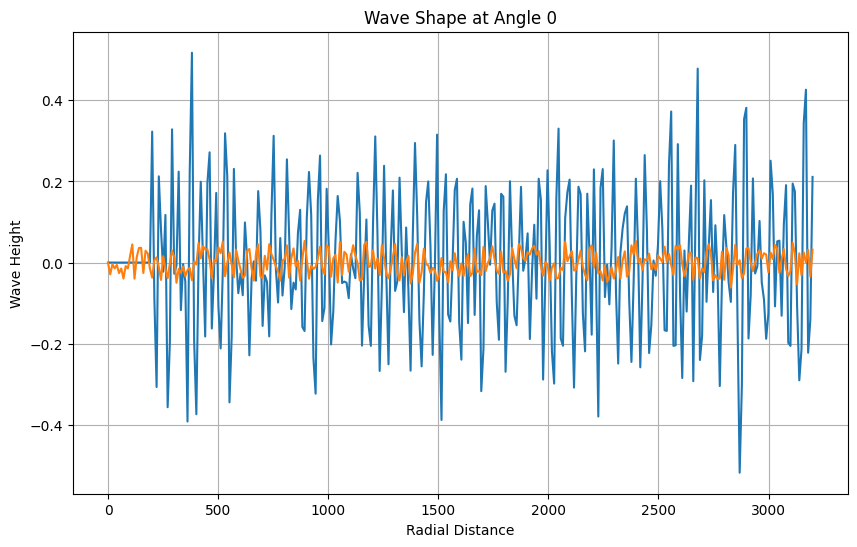

In [70]:
import matplotlib.pyplot as plt

# 选择第一帧数据和第一个角度
frame_index = 29
angle_index = 0
eta_frame = eta00[frame_index]
eta_angle = eta_frame[angle_index]


frame_index_2 = 0
angle_index_2 = 0
eta_frame_2 = a[frame_index_2]
eta_angle_2 = eta_frame_2[angle_index_2]

# 设置径向范围
r_values = np.linspace(0, 3200, 320)

# 可视化波浪形状
plt.figure(figsize=(10, 6))
plt.plot(r_values, eta_angle)
plt.plot(r_values,eta_angle_2)
plt.title('Wave Shape at Angle 0')
plt.xlabel('Radial Distance')
plt.ylabel('Wave Height')
plt.grid(True)
plt.show()